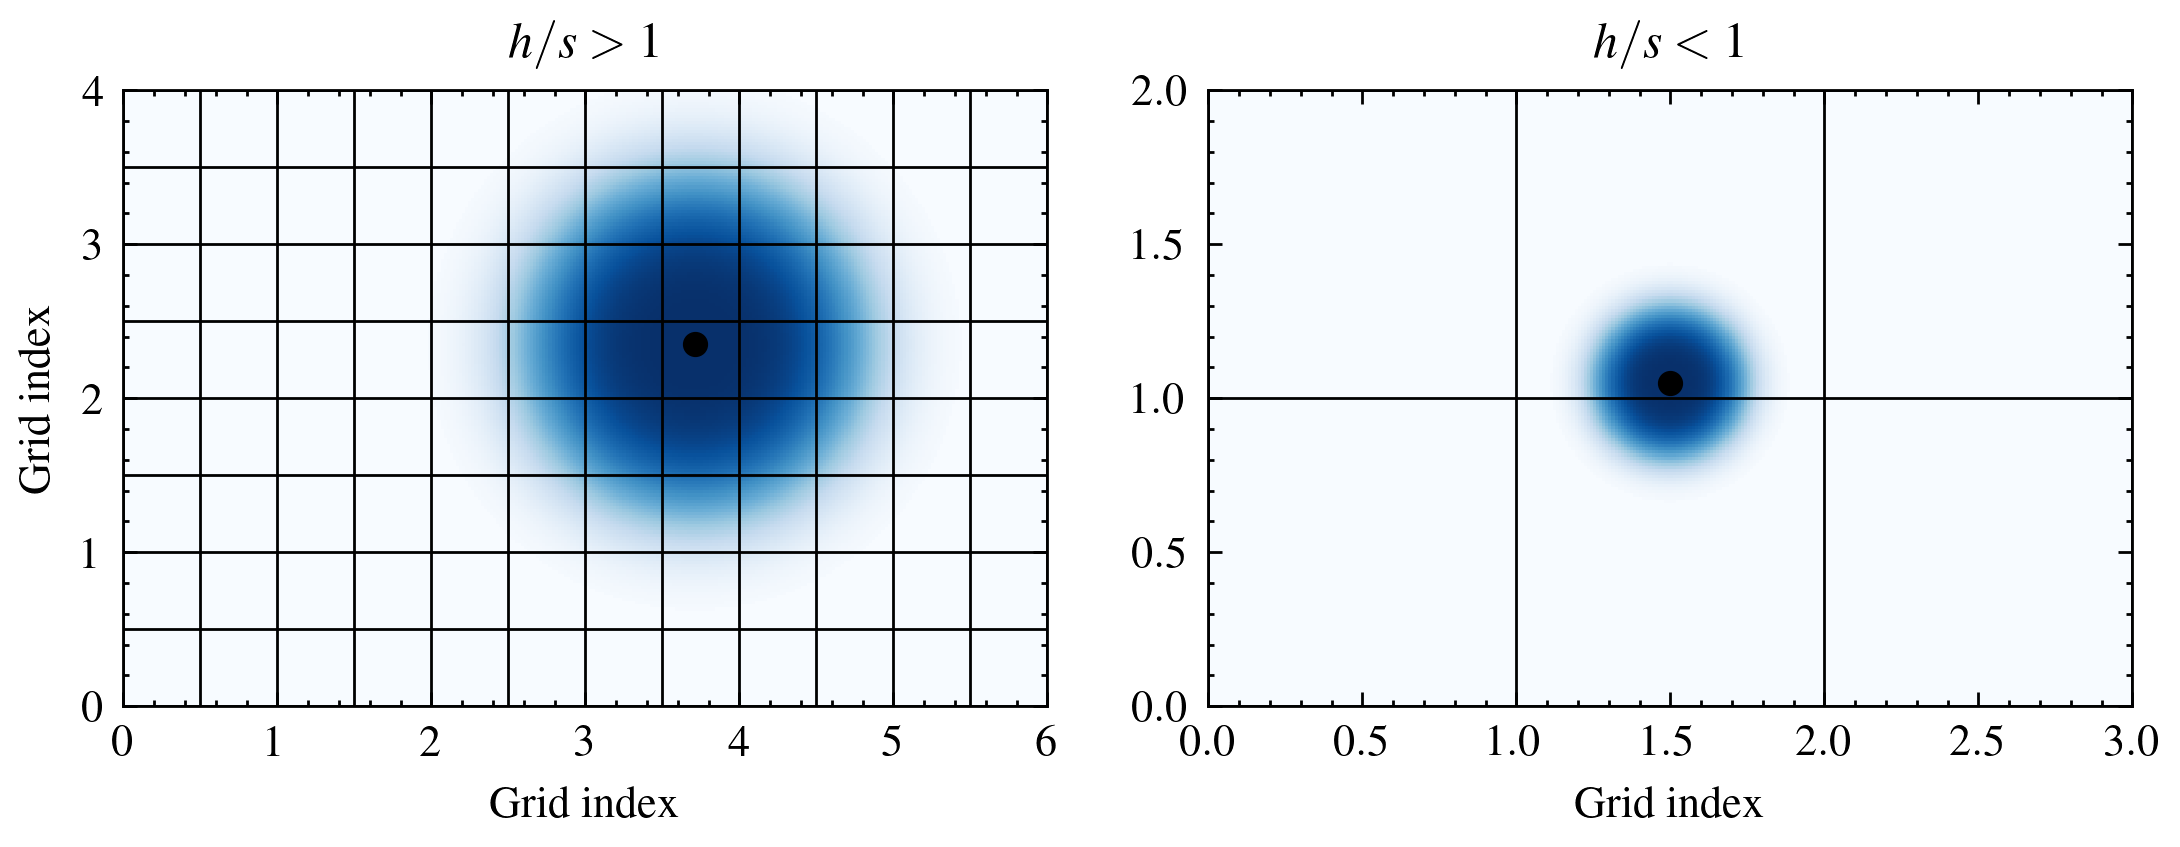

In [23]:
import matplotlib.pyplot as plt
import numpy as np

from smudgy.grid import grid_lines

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('custom')

# grid
x = np.linspace(0, 6, 300)
y = np.linspace(0, 4, 200)
X, Y = np.meshgrid(x, y)

vlines, hlines, _ = grid_lines(
    edges=[x.min(), x.max(), y.min(), y.max()],
    nx=12,
    ny=8,
    include_edges=True
    )

# Gaussian kernel centered at (0, 0)
pos_center = (3.71, 2.35)
sigma = 1.0
q = (X-pos_center[0])**2 + (Y-pos_center[1])**2
W = np.exp(-q**2 / (2*sigma**2))
W = np.where(q <= 3*sigma, W, 0)

# plot
fig, ax = plt.subplots(1, 2, figsize=(7.0, 2))
im = ax[0].imshow(W, extent=(x.min(), x.max(), y.min(), y.max()), origin="lower", cmap="Blues")
ax[0].scatter(pos_center[0], pos_center[1], color="k", marker=".", s=50, label="center")

ax[0].hlines(hlines, x.min(), x.max(), color="k", linestyle="-", lw=0.5, zorder=1)
ax[0].vlines(vlines, y.min(), y.max(), color="k", linestyle="-", lw=0.5, zorder=1)
ax[0].set_xlabel("Grid index")
ax[0].set_ylabel("Grid index")
ax[0].set_xlim(x.min(), x.max())
ax[0].set_ylim(y.min(), y.max())
ax[0].set_title(r"$h/s > 1$", fontsize=9)


# grid
x = np.linspace(0, 3, 300)
y = np.linspace(0, 2, 200)
X, Y = np.meshgrid(x, y)

vlines, hlines, _ = grid_lines(
    edges=[x.min(), x.max(), y.min(), y.max()],
    nx=3,
    ny=2,
    include_edges=True
    )

# Gaussian kernel centered at (0, 0)
pos_center = (1.5, 1.05)
sigma = 0.05
q = (X-pos_center[0])**2 + (Y-pos_center[1])**2
W = np.exp(-q**2 / (2*sigma**2))
W = np.where(q <= 3*sigma, W, 0)

# plot
ax[1].scatter(pos_center[0], pos_center[1], color="k", marker=".", s=50, label="center")
im = ax[1].imshow(W, extent=(x.min(), x.max(), y.min(), y.max()), origin="lower", cmap="Blues")
ax[1].hlines(hlines, x.min(), x.max(), color="k", linestyle="-", lw=0.5, zorder=1)
ax[1].vlines(vlines, y.min(), y.max(), color="k", linestyle="-", lw=0.5, zorder=1)
ax[1].set_xlabel("Grid index")
ax[1].set_xlim(x.min(), x.max())
ax[1].set_ylim(y.min(), y.max())
ax[1].set_title(r"$h/s < 1$", fontsize=9)

plt.savefig("kernel_anti_alias.png", dpi=400, bbox_inches="tight", transparent=False)
plt.show()

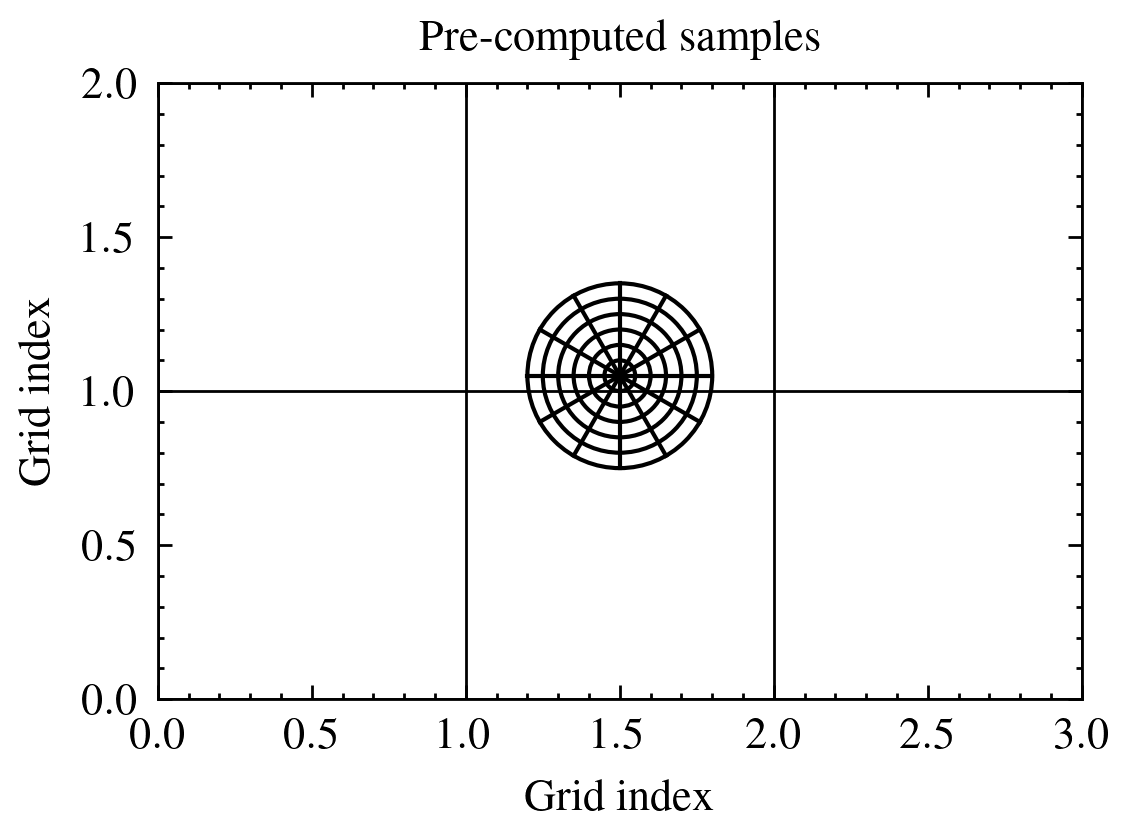

In [27]:
# Setup for the new visualization
# We use the same grid as in cell 1 but modify the second plot
x = np.linspace(0, 3, 300)
y = np.linspace(0, 2, 200)
X, Y = np.meshgrid(x, y)

pos_center = (1.5, 1.05)
sigma = 0.1  # Increased slightly for better polar grid visualization

# Grid lines for the background
from smudgy.grid import grid_lines

vlines, hlines, _ = grid_lines(
    edges=[x.min(), x.max(), y.min(), y.max()],
    nx=3,
    ny=2,
    include_edges=True
)

fig, ax = plt.subplots(figsize=(3.5, 2))

# Left subplot: Just center and border (as requested)
# Right subplot: Polar Sampling Grid (4 radial, 4 azimuthal)
ax.scatter(pos_center[0], pos_center[1], color="k", marker=".", s=10)
ax.hlines(hlines, x.min(), x.max(), color="k", linestyle="-", lw=0.5)
ax.vlines(vlines, y.min(), y.max(), color="k", linestyle="-", lw=0.5)

# Define polar grid
num_bins = 6
r_bins = np.linspace(0, 3*sigma, num_bins + 1)
theta_bins = np.linspace(0, 2*np.pi, 2*num_bins + 1)

# Plot radial circles
for r in r_bins[1:]:
    circle = plt.Circle(pos_center, r, color='k', fill=False, lw=0.75)
    ax.add_artist(circle)

# Plot azimuthal spokes
for theta in theta_bins[:-1]:
    dx = 3*sigma * np.cos(theta)
    dy = 3*sigma * np.sin(theta)
    ax.plot([pos_center[0], pos_center[0] + dx], [pos_center[1], pos_center[1] + dy], color='k', lw=0.75)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel("Grid index")
ax.set_ylabel("Grid index")
ax.set_aspect('equal')
ax.set_title("Pre-computed samples")

plt.savefig("kernel_anti_alias_samples.png", dpi=400, bbox_inches="tight", transparent=False)
plt.show()